# Milestone 1
#### Megan Alvord
## UNC MADS: Advanced Data and AI Strategy and Agentic Frameworks


## Environment Setup

In [1]:
!pip install -U langchain -q
!pip install -U langchain-openai -q
!pip install -U langchain-community -q
!pip install chromadb -q
!pip install python-dotenv -q
!pip install pypdf -q
!pip install protobuf -q
!pip install blinker -q
!pip install langchain_classic -q
!pip install langchain_chroma -q
!pip install langchain_pinecone -q
!pip install langchain_weaviate -q
!pip install langchain-text-splitters -q
!pip install pinecone -q
!pip install weaviate-client -q



In [2]:
import shutil

shutil.rmtree("./chroma_db", ignore_errors=True)

# note: this is a one time fix so I can keep working on this assignment
# if the vectorstore code is run twice at any point after this, it will just append the original vectors
# with the new vectors. So I need to figure out how to either rewrite the collection each time
# but is that the best method?

In [3]:
import pandas as pd
import time

import matplotlib.pyplot as plt
import json
import numpy as np
from pathlib import Path

from langchain_community.callbacks import get_openai_callback
from langchain_classic.chains import create_retrieval_chain
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings

from langchain_chroma import Chroma
from pinecone import Pinecone, ServerlessSpec
from langchain_pinecone import PineconeVectorStore
import weaviate
from weaviate.classes.init import Auth

import re

from langchain_weaviate import WeaviateVectorStore

from langchain_openai import ChatOpenAI
from langchain_classic.chains import create_retrieval_chain
from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_core.prompts import ChatPromptTemplate

# from langchain_community.document_loaders import Docx2txtLoader
from langchain_community.document_loaders import CSVLoader
# from langchain_community.document_loaders import UnstructuredWordDocumentLoader attempted also .doc but decided to finish the assignment first

# https://reference.langchain.com/python/langchain-community/document_loaders

C:\Users\mealv\AppData\Local\Temp\ipykernel_10400\1638039864.py:9: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.callbacks import get_openai_callback


In [4]:
import os
from dotenv import load_dotenv

load_dotenv()

# ── UNC AI Gateway (Azure API Management in front of Azure OpenAI — OpenAI-compatible v1 API) ──
# One key, one endpoint, every course model. Your personal key arrives via Canvas Inbox.
# Create a .env file next to this notebook containing a single line:
#   UNC_AI_API_KEY=your-key-here
# ⚠️  Never paste your key into a notebook cell — notebooks get submitted!
UNC_AI_BASE_URL = "https://azureaiapi.cloud.unc.edu/openai/v1"
UNC_AI_API_KEY = os.getenv("UNC_AI_API_KEY") or os.getenv("OPENAI_API_KEY")
assert UNC_AI_API_KEY, "Missing UNC_AI_API_KEY — check the Canvas Inbox message with your personal key"

# Course model lineup (deployment names on the gateway match the model names)
CHAT_MODEL = os.getenv("UNC_CHAT_MODEL", "gpt-4.1-mini")        # everyday workhorse
ADVANCED_MODEL = os.getenv("UNC_ADVANCED_MODEL", "gpt-5.6-sol")  # frontier tier for harder tasks
EMBED_MODEL = os.getenv("UNC_EMBED_MODEL", "text-embedding-3-small")

# Let every OpenAI-compatible library (LangChain, LlamaIndex, CrewAI, AutoGen…) find the gateway:
os.environ["OPENAI_API_KEY"] = UNC_AI_API_KEY
os.environ["OPENAI_BASE_URL"] = UNC_AI_BASE_URL

# Gateway policy: if you ever use the Responses API, set store=False and never background=True.

print("✓ UNC AI Gateway configured")
print(f"  Chat: {CHAT_MODEL}  |  Advanced: {ADVANCED_MODEL}  |  Embeddings: {EMBED_MODEL}")

✓ UNC AI Gateway configured
  Chat: gpt-4.1-mini  |  Advanced: gpt-5.6-sol  |  Embeddings: text-embedding-3-small


## Set up the models

In [5]:
print(f"Gateway: {UNC_AI_BASE_URL}")
print(f"Embedding model: {EMBED_MODEL}")

# Embeddings through the UNC AI Gateway
try:
    embeddings = OpenAIEmbeddings(
        model=EMBED_MODEL,
        base_url=UNC_AI_BASE_URL,
        api_key=UNC_AI_API_KEY,
    )

    # Test with a simple embedding
    print("Testing embedding with single text...")
    test_embedding = embeddings.embed_query("test")
    print(f"✓ Embedding successful! Vector dimension: {len(test_embedding)}")

except Exception as e:
    print(f"✗ Embedding failed: {e}")
    print("\nTroubleshooting:")
    print("1. Confirm UNC_AI_API_KEY is set in your .env file")
    print("2. Verify your key works: it was sent to you via Canvas Inbox")
    print("3. Check the model name — see the course model lineup in the setup cell")
    raise

print("✓ Embeddings client ready")

Gateway: https://azureaiapi.cloud.unc.edu/openai/v1
Embedding model: text-embedding-3-small
Testing embedding with single text...
✓ Embedding successful! Vector dimension: 1536
✓ Embeddings client ready


## Load the Documents

File types: pdf only for bare bones RAG

In [6]:
# Primary path:
pdf_paths = [
    Path("rag_sp1.pdf"),
    Path("rag_sp2.pdf"),
    Path("rag_sp3.pdf"),
    Path("rag_sp4.pdf"),
    Path("rag_sp5.pdf"),
    Path("rag_sp6.pdf"),
    Path("rag_sp7.pdf")
]

documents = []

for pdf_path in pdf_paths:
    if pdf_path.exists():
        pages = PyPDFLoader(str(pdf_path)).load()
        documents.extend(pages) # combines pdfs into document
        print(f"Loaded {len(pages)} page(s) from {pdf_path.name}")

print(f"Total pages loaded: {len(documents)}")     

Loaded 8 page(s) from rag_sp1.pdf
Loaded 8 page(s) from rag_sp2.pdf
Loaded 13 page(s) from rag_sp3.pdf
Loaded 31 page(s) from rag_sp4.pdf
Loaded 3 page(s) from rag_sp5.pdf
Loaded 6 page(s) from rag_sp6.pdf
Loaded 13 page(s) from rag_sp7.pdf
Total pages loaded: 82


In [7]:
print(f"\nPreview ({len(documents[0].page_content)} characters):")
print(documents[0].page_content[:500] + "...")


Preview (7671 characters):
HORTSCIENCE 50(11):1610–1617. 2015.
The Carbohydrate Yield of Sweetpotato
(Ipomoea batatas) Grown from Slips
and Root Pieces in North Carolina
Nicholas A. George
Department of Horticultural Science, North Carolina State University, 214
Kilgore Hall, Campus Box 7609, Raleigh, NC 27695; and Department of
Plant Sciences, the University of California, Davis, One Shields Avenue
Davis, CA 95616
Kenneth V. Pecota and G. Craig Yencho 1
Department of Horticultural Science, North Carolina State University...


## The Bare Minimum RAG

In [8]:
# Larger chunks - better for nuanced questions
splitter_large = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=50,
    length_function=len,
    separators=["\n\n", "\n", ". ", " ", ""]
)

chunks_large = splitter_large.split_documents(documents)
print(f"Large chunks (1000 chars): {len(chunks_large)} chunks")

Large chunks (1000 chars): 496 chunks


In [9]:
client = weaviate.connect_to_weaviate_cloud(
    cluster_url=os.environ["WEAVIATE_URL"],
    auth_credentials=Auth.api_key(os.environ["WEAVIATE_API_KEY"]),
)

In [10]:
print(client.is_ready())

True


In [11]:
# the following was from AI to sanitize the metadata so weaviate would work

def sanitize_metadata(metadata: dict) -> dict:
    clean = {}
    for key, value in metadata.items():
        new_key = re.sub(r'[^_0-9A-Za-z]', '_', key)
        # Weaviate also requires the first char to be a letter or underscore
        if new_key[0].isdigit():
            new_key = f"_{new_key}"
        clean[new_key] = value
    return clean



In [12]:
chunks_large_weaviate = [
    Document(page_content=c.page_content, metadata=sanitize_metadata(c.metadata))
    for c in chunks_large
]

In [13]:
# client.collections.delete("RAG_large") # in case anything was stored in here previously

In [14]:
# metadatas_clean = [sanitize_metadata(m) for m in metadatas] # cleaning metadata in case anything was stored here previously
# only need on reruns

In [15]:
texts = [c.page_content for c in chunks_large_weaviate]
metadatas = [c.metadata for c in chunks_large_weaviate]

embedded_vectors = embeddings.embed_documents(texts)

vectorstore_weaviate = WeaviateVectorStore.from_documents(
    documents=chunks_large_weaviate,
    embedding=embeddings,
    client=client,
    index_name="RAG_large"  # Weaviate class names are typically capitalized
)

collection = client.collections.get("RAG_large")
response = collection.aggregate.over_all(total_count=True)
print(f"\n✓ Vector store created with {response.total_count} vectors")


✓ Vector store created with 496 vectors


In [16]:

# Chat model through the UNC AI Gateway
llm = ChatOpenAI(
    model=CHAT_MODEL, # 4.1 mini is default 
    base_url=UNC_AI_BASE_URL,
    api_key=UNC_AI_API_KEY,
    temperature=0,
)

prompt = ChatPromptTemplate.from_template(
    """Answer the question based only on the following context:

{context}

Question: {input}"""
)

combine_docs_chain = create_stuff_documents_chain(llm, prompt)


qa_chain_weaviate = create_retrieval_chain(
    retriever=vectorstore_weaviate.as_retriever(search_kwargs={"k": 3}),
    combine_docs_chain=combine_docs_chain
)

print("✓ RAG chain ready")
print(f"  Using model: {CHAT_MODEL} via the UNC AI Gateway")

✓ RAG chain ready
  Using model: gpt-4.1-mini via the UNC AI Gateway


In [17]:
# 5 question test set

# page numbers offset by 1
gold_5_dataset = [
    {"query": "How is carotenoid bioaccessibility defined?",
        "expected_sources": [{"source": "rag_sp3.pdf", "page": 4}],
        
    },
    {"query": "Who maintains the US sweetpotato germplasm collection?",
        "expected_sources": [{"source": "rag_sp7.pdf", "page": 1}],
        
    },
    {"query": "What has lead to the reemergence of black rot in North Carolina sweet potatoes?",
        "expected_sources": [{"source": "rag_sp2.pdf", "page": 6}, {"source": "rag_sp4.pdf", "page": 12}]
       
    },
    {"query": "How many sweet potatoes did the US produce in 2000?",
        "expected_sources": [{"source": "rag_sp6.pdf", "page": 0}],
        
    },
    {"query": "What are signs of weevil infestation in sweet potatoes?",
        "expected_sources": [{"source": "rag_sp4.pdf", "page": 10}],
        
    },
]

In [18]:
def ask_question(question: str):

    response = qa_chain_weaviate.invoke({"input": question})

    print(f"Q: {question}")
    print("=" * 60)
    print("ANSWER:")
    print(response["answer"])
    print("=" * 60)


    # Used AI to write this part. 
    sources = response["context"]
    print(f"\n[Retrieved {len(sources)} sources]")
    for i, doc in enumerate(sources, 1):
        print(f"\n Source {i} {doc.metadata.get('source', 'N/A')} (Page {doc.metadata.get('page', 'N/A')})")

    return response

In [19]:
for item in gold_5_dataset:
    query = item["query"]
    _ = ask_question(query)

Q: How is carotenoid bioaccessibility defined?
ANSWER:
Carotenoid bioaccessibility is defined as the fraction of carotenoids transferred by food to mixed micelles, therefore becoming accessible for subsequent uptake by the intestinal mucosa.

[Retrieved 3 sources]

 Source 1 rag_sp3.pdf (Page 4.0)

 Source 2 rag_sp3.pdf (Page 4.0)

 Source 3 rag_sp3.pdf (Page 3.0)
Q: Who maintains the US sweetpotato germplasm collection?
ANSWER:
The US sweetpotato germplasm collection and its crop wild relatives are maintained at Griffin, Georgia, by the Plant Genetic Resources Conservation Unit, which is part of the United States Department of Agriculture, Agricultural Research Service (USDA-ARS).

[Retrieved 3 sources]

 Source 1 rag_sp7.pdf (Page 1.0)

 Source 2 rag_sp7.pdf (Page 0.0)

 Source 3 rag_sp4.pdf (Page 6.0)
Q: What has lead to the reemergence of black rot in North Carolina sweet potatoes?
ANSWER:
The reemergence of black rot of sweetpotato in North Carolina stems from a seemingly genetica

<br>
Above shows a complete, but brief RAG pipeline. The loop runs end to end on five questions: retrieve → answer → sources.



## Load the Documents

File types: pdf, htm, csv

In [20]:
!pip install beautifulsoup4 lxml -q

C:\Users\mealv\anaconda3\Lib\site-packages\IPython\utils\_process_win32.py:124: ResourceWarning: unclosed file <_io.BufferedWriter name=3>
  return process_handler(cmd, _system_body)
C:\Users\mealv\anaconda3\Lib\site-packages\IPython\utils\_process_win32.py:124: ResourceWarning: unclosed file <_io.BufferedReader name=4>
  return process_handler(cmd, _system_body)
C:\Users\mealv\anaconda3\Lib\site-packages\IPython\utils\_process_win32.py:124: ResourceWarning: unclosed file <_io.BufferedReader name=5>
  return process_handler(cmd, _system_body)


In [21]:
from langchain_community.document_loaders import BSHTMLLoader

In [22]:
# Claude generated to help with htm files 

import hashlib
from bs4 import BeautifulSoup
from langchain_core.documents import Document
from langchain_text_splitters import HTMLHeaderTextSplitter, RecursiveCharacterTextSplitter
from pathlib import Path

HEADERS = [("h1", "h1"), ("h2", "h2"), ("h3", "h3")]
html_splitter = HTMLHeaderTextSplitter(headers_to_split_on=HEADERS)
char_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1500, chunk_overlap=150, add_start_index=True  # match your existing settings
)

def load_htm(path: str) -> list[Document]:
    raw = Path(path).read_text(encoding="utf-8", errors="ignore")
    soup = BeautifulSoup(raw, "html.parser")

    title = soup.title.get_text(strip=True) if soup.title else ""

    for tag in soup(["script", "style", "noscript", "iframe", "svg", "nav", "footer", "header", "form"]):
        tag.decompose()
    cleaned = str(soup)

    sections = html_splitter.split_text(cleaned)
    docs = []
    for i, s in enumerate(sections):
        section = " > ".join(s.metadata[k] for k in ("h1", "h2", "h3") if k in s.metadata)
        docs.append(Document(
            page_content=s.page_content,
            metadata={"source": path, "title": title,
                      "section": section or f"section_{i}", "section_idx": i},
        ))
    return docs

def add_chunk_ids(chunks: list[Document]) -> list[Document]:
    for c in chunks:
        m = c.metadata
        key = f"{m.get('source')}|{m.get('page')}|{m.get('row')}|{m.get('section_idx')}|{m.get('start_index')}"
        m["chunk_id"] = hashlib.sha1(key.encode()).hexdigest()[:12]
    return chunks

In [23]:
def load_document(file_path):
    path = Path(file_path)
    suffix = path.suffix.lower()

    if suffix == ".pdf":
        docs = PyPDFLoader(str(path)).load()      # metadata: source, page (0-indexed)
        ftype = "pdf"
        
    elif suffix == ".csv":
        docs = CSVLoader(str(path)).load()        # metadata: source, row
        ftype = "csv"
        
    elif suffix in (".htm", ".html"):
        docs = load_htm(str(path))                # metadata: source, title, section, section_idx
        ftype = "html"
    else:
        raise ValueError(f"Unsupported file type: {path.suffix}")

    # elif suffix == ".docx":
    #     loader = Docx2txtLoader(str(path))

    for d in docs:
        d.metadata["file_type"] = ftype
        
    return docs

In [24]:
data_dir = Path(".")

files = list(data_dir.glob("*.pdf"))
files += list(data_dir.glob("*.htm"))
files += list(data_dir.glob("*.csv"))

print(f"Found {len(files)} files")

Found 14 files


In [25]:
all_documents = []

for file in files:
    docs = load_document(file)
    all_documents.extend(docs)

    print(f"{file.name}: {len(docs)} documents")

print(f"Total documents loaded: {len(all_documents)}")    

rag_sp1.pdf: 8 documents
rag_sp2.pdf: 8 documents
rag_sp3.pdf: 13 documents
rag_sp4.pdf: 31 documents
rag_sp5.pdf: 3 documents
rag_sp6.pdf: 6 documents
rag_sp7.pdf: 13 documents
sp_wb3.htm: 25 documents
sp_wb4.htm: 25 documents
sp_wb5.htm: 25 documents
sp_wp1.htm: 27 documents
sp_wp2.htm: 25 documents
sp_table2.csv: 737 documents
sp_table3.csv: 203 documents
Total documents loaded: 1149


In [26]:
# check to make sure this is actually what I wanted! 

# should be from a pdf
print(f"\nPreview ({len(all_documents[0].page_content)} characters):")
print(all_documents[0].page_content[:500] + "...")
print("\n")
# should be from a htm file
print(f"\nPreview ({len(all_documents[8].page_content)} characters):")
print(all_documents[8].page_content[:600] + "...")
print("\n")
# should be from a csv file
print(f"\nPreview ({len(all_documents[-1].page_content)} characters):")
print(all_documents[-1].page_content[:500] + "...")



Preview (7671 characters):
HORTSCIENCE 50(11):1610–1617. 2015.
The Carbohydrate Yield of Sweetpotato
(Ipomoea batatas) Grown from Slips
and Root Pieces in North Carolina
Nicholas A. George
Department of Horticultural Science, North Carolina State University, 214
Kilgore Hall, Campus Box 7609, Raleigh, NC 27695; and Department of
Plant Sciences, the University of California, Davis, One Shields Avenue
Davis, CA 95616
Kenneth V. Pecota and G. Craig Yencho 1
Department of Horticultural Science, North Carolina State University...



Preview (7222 characters):
Genetic Diversity, Fungicide Sensitivity, and Host Resistance
to Ceratocystis fimbriata Infecting Sweetpotato in North Carolina
A. C. Scruggs,Department of Plant Pathology, North Carolina State University, Raleigh 27695;T. Basaiah,Department of Microbiology,
Kuvempu University, Shimoga, Karnataka, India; andM. L. Adamsand L. M. Quesada-Ocampo,Department of Plant Pathology, North
Carolina State University, Raleigh 27695
Abstract
Black 

## Gold Set (started in Lab 4 and grown)

In Lab 4, I developed a gold set of 10 questions. I decided to expand my file types to include csv and htm/html files. Almost all of this came from a series of Claude conversations, but the selection of the questions to add was me. 

In [27]:
# page numbers offset by 1
gold_dataset = [
    {"query": "How is carotenoid bioaccessibility defined?",
        "expected_sources": [{"source": "rag_sp3.pdf", "page": 4}],
        
    },
    {"query": "Who maintains the US sweetpotato germplasm collection?",
        "expected_sources": [{"source": "rag_sp7.pdf", "page": 1}],
        
    },
    {"query": "What has lead to the reemergence of black rot in North Carolina sweet potatoes?",
        "expected_sources": [{"source": "rag_sp2.pdf", "page": 6}, {"source": "rag_sp4.pdf", "page": 12}]
       
    },
    {"query": "How many sweet potatoes did the US produce in 2000?",
        "expected_sources": [{"source": "rag_sp6.pdf", "page": 0}],
        
    },
    {"query": "What are signs of weevil infestation in sweet potatoes?",
        "expected_sources": [{"source": "rag_sp4.pdf", "page": 10}],
        
    },
    {"query": "What is the impact of rising atmospheric carbon dioxide on sweet potatoes?",
        "expected_sources": [{"source": "rag_sp4.pdf", "page": 16}],
       
    },
    {"query": "Who is the top global producer of sweet potatoes?",
        "expected_sources": [{"source": "rag_sp6.pdf", "page": 4}],
        
    },
    {"query": "Is there a difference when planting sweet potatoes via slips versus via root pieces in experimental results?",
        "expected_sources": [{"source": "rag_sp1.pdf", "page": 6}],
       
    },
    {"query": "What are the best sources for vitamin A?",
        "expected_sources": [{"source": "rag_sp3.pdf", "page": 2}],
        
    },
    {"query": "What are the results of the UDSA sweet potato breeding program?",
        "expected_sources": [{"source": "rag_sp7.pdf", "page": 10}],
       
    },
]

In [28]:
import random
from pydantic import BaseModel, Field
from collections import defaultdict

random.seed(42) # I sure hope this works! 

In [29]:
chunks_large_all = splitter_large.split_documents(all_documents)
print(f"Large chunks (1000 chars): {len(chunks_large_all)} chunks")



Large chunks (1000 chars): 1585 chunks


In [30]:
chunks_for_gold = [
    Document(page_content=c.page_content, metadata=sanitize_metadata(c.metadata))
    for c in chunks_large_all
]

In [31]:
def file_type(chunk):
    ft = chunk.metadata.get("file_type")
    if ft:
        return ft
    ext = chunk.metadata.get("source", "").rsplit(".", 1)[-1].lower()
    return "html" if ext in ("htm", "html") else ext

MIN_LEN = {"csv": 100, "pdf": 500, "html": 400}
per_type = {"html": 15, "csv": 15, "pdf": 5}   # only one definition

def filled_fields(chunk):
    """Return {column: value} for non-empty fields only."""
    out = {}
    for line in chunk.page_content.splitlines():
        if ":" in line:
            k, v = line.split(":", 1)
            if v.strip():
                out[k.strip()] = v.strip()
    return out

MIN_FILLED = 4   # tune after looking at your data

def long_enough(c):
    text = c.page_content
    ft = file_type(c)
    if ft == "csv":
        return len(filled_fields(c)) >= MIN_FILLED
    if len(text) <= MIN_LEN.get(ft, 500):
        return False
    if ft == "html" and looks_like_code(text):
        return False
    if dupe_counts[norm(text)] > 1:
        return False
    return True
    
def long_enough(c):
    return len(c.page_content) > MIN_LEN.get(file_type(c), 500)

by_type = defaultdict(list)
for c in chunks_for_gold:
    if long_enough(c):
        by_type[file_type(c)].append(c)
print({k: len(v) for k, v in by_type.items()})

sampled = []
for ftype, n in per_type.items():
    pool = by_type.get(ftype, [])
    if not pool:
        print(f"WARNING: no eligible chunks for '{ftype}'")
    sampled += random.sample(pool, min(n, len(pool)))
print("sampled:", len(sampled))

def csv_passage(chunk):
    return "\n".join(f"{k}: {v}" for k, v in filled_fields(chunk).items())
    
class GoldQA(BaseModel):
    query: str = Field(description="A self-contained question answerable from the passage")
    reference_answer: str = Field(description="The correct answer, based only on the passage")

structured_llm = llm.with_structured_output(GoldQA)

prompt = """You are writing evaluation questions for a RAG system.

Read the passage below and write ONE question that can be answered using only this passage.

Rules:
- The question must make sense on its own. Never say "according to the passage/text/document".
- Don't copy phrasing from the passage; paraphrase so retrieval isn't trivially keyword-matched.
- Ask about a specific fact, explanation, or relationship, not something vague.
- The reference answer must be fully supported by the passage.

Passage:
{passage}
"""

csv_prompt = """Write ONE question for a RAG evaluation set that can be answered
from the record below alone. The person asking has never seen the data and will not be able to see the row
as part of the question.

- Identify the record using one or two of its values (for example a name or clone number).
- Ask about one other value in the record, in natural wording rather than column labels.
- Do not use the words entry, row, record, table, column, or dataset.

Record:
{passage}
"""

# Claude helped for document type specific metadata recording
def gold_record(chunk, qa):
    m = chunk.metadata
    return {
        "query": qa.query,
        "reference_answer": qa.reference_answer,
        "file_type": file_type(chunk),
        "source": m.get("source"),
        "page": m.get("page"),            # pdf
        "row": m.get("row"),              # csv
        "section": m.get("section"),      # htm
        "section_idx": m.get("section_idx"),
        "start_index": m.get("start_index"),
        "chunk_id": m.get("chunk_id"),
        "source_chunk": chunk.page_content,
        "origin": "generated",
    }

generated = []
for chunk in sampled:
    p = csv_prompt if file_type(chunk) == "csv" else prompt
    qa = structured_llm.invoke(p.format(passage=chunk.page_content))
    generated.append(gold_record(chunk, qa))

{'pdf': 453, 'html': 48, 'csv': 940}
sampled: 35


In [32]:
for i, g in enumerate(generated):
    print(f"--- {i} ---")
    print("FILE:", g["source"], f"({g['file_type']})")

    # show whichever location field exists for this file type
    if g.get("page") is not None:
        print("PAGE:", g["page"])
    if g.get("row") is not None:
        print("ROW:", g["row"])

    print("Q:", g["query"])
    print("A:", g["reference_answer"])
    print("CHUNK:", g["source_chunk"][:800], "\n")

--- 0 ---
FILE: sp_wp2.htm (html)
Q: What type of organism is responsible for causing Geotrichum sour rot?
A: Geotrichum sour rot is caused by the ascomycete fungus Geotrichum candidum.
CHUNK: Skip to Pathogen  
Geotrichum sour rot is caused by the ascomycete fungus ( ).  
Geotrichum candidum  
Figure 1  
Modal  
Figure 1. Geotrichum candidum observed under the microscope at 40x magnification.  
Dr. Lina Quesada, NC State Vegetable Pathology Lab  
×  
Figure 1. Geotrichum candidum observed under the microscope at 40x magnification.  
Dr. Lina Quesada, NC State Vegetable Pathology Lab  
Print Image 

--- 1 ---
FILE: sp_wb3.htm (html)
Q: What precautions should individuals take before applying agricultural chemicals according to the guidelines provided?
A: Individuals should ensure that the intended use of agricultural chemicals complies with current regulations and matches the product label, obtain current information about usage regulations, and examine a current product label before a

In [33]:
 # indices from the printed "--- i ---" headers
keep = [1,2,3,4,5,6,8,10,11,12, # htm
       15,16,17,18,19,21,20,23,24,25,26,  # csv
       30,33,34]  # few extra pdf

LOC_KEY = {"pdf": "page", "csv": "row", "html": "section_idx"}

def to_gold(g):
    loc_key = LOC_KEY[g["file_type"]]
    return {
        "query": g["query"],
        "expected_sources": [{
            "source": Path(g["source"]).name,   # "rag_sp3.pdf", not a full path
            loc_key: g[loc_key],
        }],
        # optional extras; harmless if you never use them
        "reference_answer": g["reference_answer"],
        "origin": "generated",
    }

new_items = [to_gold(generated[i]) for i in keep]
gold_dataset.extend(new_items)

print(len(gold_dataset))
for item in new_items:
    print(item["query"], "->", item["expected_sources"])

34
What precautions should individuals take before applying agricultural chemicals according to the guidelines provided? -> [{'source': 'sp_wb3.htm', 'section_idx': 24}]
What are the characteristics and development process of the sclerotia formed by Sclerotium rolfsii on sweetpotato plants? -> [{'source': 'sp_wb3.htm', 'section_idx': 8}]
What precautions should be taken to prevent the introduction of root knot nematodes into seed and production fields? -> [{'source': 'sp_wb4.htm', 'section_idx': 14}]
What are the effects of the root knot nematode Meloidogyne enterolobii on sweetpotato roots? -> [{'source': 'sp_wb4.htm', 'section_idx': 8}]
What type of damage does Meloidogyne enterolobii cause to sweetpotato plants? -> [{'source': 'sp_wb4.htm', 'section_idx': 8}]
Which two species of root knot nematodes are primarily responsible for significant damage to sweetpotato crops? -> [{'source': 'sp_wb4.htm', 'section_idx': 4}]
How does Fusarium solani persist in the environment and contribute 

## Chunking Strategies

Definitely had plans to do this with Weaviate. Instead ran with Chroma

In [34]:
# Strategy 1: Small chunks - better for specific fact retrieval
splitter_small = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50,
    length_function=len,
    separators=["\n\n", "\n", ". ", " ", ""]
)

chunks_small = splitter_small.split_documents(all_documents)
print(f"Small chunks (500 chars): {len(chunks_small)} chunks")

# Strategy 2: Larger chunks - better for nuanced questions
splitter_large = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=50,
    length_function=len,
    separators=["\n\n", "\n", ". ", " ", ""]
)

chunks_large = splitter_large.split_documents(all_documents)
print(f"Large chunks (1000 chars): {len(chunks_large)} chunks")

# Strategy 3: Larger chunks and larger overlap
splitter_large_greater_overlap = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    length_function=len,
    separators=["\n\n", "\n", ". ", " ", ""]
)

chunks_large_with_overlap = splitter_large_greater_overlap.split_documents(all_documents)
print(f"Large chunks (1000 chars) with larger overlap: {len(chunks_large_with_overlap)} chunks")

Small chunks (500 chars): 2125 chunks
Large chunks (1000 chars): 1585 chunks
Large chunks (1000 chars) with larger overlap: 1656 chunks


In [35]:
# NOT DEAD CODE!!!

# # for reruns
# # check these first...if error, then you're good! they haven't been made yet
# print(vectorstore_small._collection.count())
# print(vectorstore_large._collection.count())
# print(vectorstore_large_overlap._collection.count())

# # if those do run, then do these to remove them
# vectorstore_small.delete_collection()
# vectorstore_large.delete_collection()
# vectorstore_large_overlap.delete_collection()


In [36]:
# Create the vector store for the small chunk strategy
print(f"Embedding {len(chunks_small)} chunks...")

vectorstore_small = Chroma.from_documents(
    documents=chunks_small, # these are the chunked document objects
    embedding=embeddings, # tells which embeddings modelto call 
    persist_directory="./chroma_db", # folder for Chroma    
    collection_name="rag_small" # this is the name of the collection of vectors within Chroma
)

print(f"\n✓ Vector store created with {vectorstore_small._collection.count()} vectors")

# Create the vector store for the large chunk strategy
print(f"Embedding {len(chunks_large)} chunks...")

vectorstore_large = Chroma.from_documents(
    documents=chunks_large,
    embedding=embeddings,
    persist_directory="./chroma_db",
    collection_name="rag_large"
)

print(f"\n✓ Vector store created with {vectorstore_large._collection.count()} vectors")

# Create the vector store for the large chunk with extra overlap strategy
print(f"Embedding {len(chunks_large_with_overlap)} chunks...")

vectorstore_large_overlap = Chroma.from_documents(
    documents=chunks_large_with_overlap,
    embedding=embeddings,
    persist_directory="./chroma_db",
    collection_name="rag_large_overlap"
)

print(f"\n✓ Vector store created with {vectorstore_large_overlap._collection.count()} vectors")

Embedding 2125 chunks...

✓ Vector store created with 2125 vectors
Embedding 1585 chunks...

✓ Vector store created with 1585 vectors
Embedding 1656 chunks...

✓ Vector store created with 1656 vectors


In [37]:
from langchain_openai import ChatOpenAI
from langchain_classic.chains import RetrievalQA

# Chat model through the UNC AI Gateway
llm = ChatOpenAI(
    model=CHAT_MODEL, # 4.1 mini is default 
    base_url=UNC_AI_BASE_URL,
    api_key=UNC_AI_API_KEY,
    temperature=0,
)

In [38]:
# Create the retrieval chain for each strategy 
qa_chain_small = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=vectorstore_small.as_retriever(search_kwargs={"k": 3}),
    return_source_documents=True
)

qa_chain_large = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=vectorstore_large.as_retriever(search_kwargs={"k": 3}),
    return_source_documents=True
)

qa_chain_large_overlap = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=vectorstore_large_overlap.as_retriever(search_kwargs={"k": 3}),
    return_source_documents=True
)

In [39]:
# AI helped for getting metadata for different document types 
# pdf --> page, csv --> row, html --> idx

def location_of(doc):
    meta = doc.metadata
    suffix = Path(meta.get("source", "")).suffix.lower()

    if suffix == ".pdf":
        page = meta.get("page")
        return {"page": page} if page is not None else {}

    if suffix == ".csv":
        row = meta.get("row")
        return {"row": row} if row is not None else {}

    if suffix in (".htm", ".html"):
        idx = meta.get("section_idx")
        return {"section_idx": idx} if idx is not None else {}

    return {}


def make_key(source, location):
    return (
        Path(source).name,
        tuple(sorted(location.items()))
    )
from langchain_core.documents import Document

def to_gold(g):
    doc = Document(page_content="", metadata={
        "source": g["source"], "page": g.get("page"),
        "row": g.get("row"), "section_idx": g.get("section_idx"),
    })
    loc = location_of(doc)
    assert loc, f"No location for {g['source']}"
    return {
        "query": g["query"],
        "expected_sources": [{"source": Path(g["source"]).name, **loc}],
        "reference_answer": g["reference_answer"],
        "origin": "generated",
    }

In [40]:
def evaluate_retrieval_strategies(gold_dataset, retrievers_dict):
    rows = []

    for strategy_name, retriever in retrievers_dict.items():

        for item in gold_dataset:

            # Claude generated for help with multiple file types
            # What sources/locations should have been retrieved?
            expected_keys = {
                make_key(
                    expected["source"],
                    {
                        k: v
                        for k, v in expected.items()
                        if k != "source"
                    }
                )
                for expected in item["expected_sources"]
            }

            # What did the retriever actually return?
            retrieved_docs = retriever.invoke(item["query"])

            retrieved_keys = [
                make_key(
                    doc.metadata.get("source", ""),
                    location_of(doc)
                )
                for doc in retrieved_docs
            ]

            # Looking back through this, I can definitely say this is my logic, but not my coding style
            # This isn't how I code... Why did Claude feel the need to change it other than the variable names?
            
            # Rank of first correct result
            first_rank = next(
                (
                    rank
                    for rank, key in enumerate(retrieved_keys, start=1)
                    if key in expected_keys
                ),
                None
            )

            # Metrics for this question
            hit = int(first_rank is not None)

            reciprocal_rank = (
                1 / first_rank
                if first_rank is not None
                else 0.0
            )

            recall = (
                len(expected_keys & set(retrieved_keys))
                / len(expected_keys)
                if expected_keys
                else 0.0
            )

            precision = (
                sum(key in expected_keys for key in retrieved_keys)
                / len(retrieved_keys)
                if retrieved_keys
                else 0.0
            )

            rows.append({
                "strategy": strategy_name,
                "filetype": Path(
                    item["expected_sources"][0]["source"]
                ).suffix.lower().lstrip("."),
                "query": item["query"],
                "hit": hit,
                "reciprocal_rank": reciprocal_rank,
                "recall": recall,
                "precision": precision,
                "expected_sources": item["expected_sources"],

                    # Keep track of what the retriever actually returned
                "retrieved_sources": [
                    {
                        "source": Path(doc.metadata.get("source", "")).name,
                        "page": doc.metadata.get("page"),
                        "row": doc.metadata.get("row"),
                        "section_idx": doc.metadata.get("section_idx")
                    }
                    for doc in retrieved_docs
                ]
            })

    return pd.DataFrame(rows)


In [41]:
retrievers = {
    "Small Chunks (500/50)": vectorstore_small.as_retriever(search_kwargs={"k": 3}),
    "Large Chunks (1000/50)": vectorstore_large.as_retriever(search_kwargs={"k": 3}),
    "Large Chunks Larger Overlap (1000/200)": vectorstore_large_overlap.as_retriever(search_kwargs={"k": 3}),
}


per_q = evaluate_retrieval_strategies(gold_dataset,retrievers)

In [42]:
# This was the same intention as my Lab 4 output, which I pasted into ChatGPT to get help for updating with the multiple file types
overall = (
    per_q
    .groupby("strategy")
    .agg(
        n=("hit", "count"),
        hit_rate=("hit", "mean"),
        recall=("recall", "mean"),
        mrr=("reciprocal_rank", "mean"),
        precision=("precision", "mean"),
    )
    .round(3)
)

print(overall)

                                         n  hit_rate  recall    mrr  precision
strategy                                                                      
Large Chunks (1000/50)                  34     0.912   0.897  0.814      0.382
Large Chunks Larger Overlap (1000/200)  34     0.824   0.809  0.770      0.363
Small Chunks (500/50)                   34     0.794   0.794  0.735      0.353


In [43]:
# This part was coded by ChatGPT. I wanted to see how each file type compared

by_type = (
    per_q
    .groupby(["filetype", "strategy"])
    .agg(
        n=("hit", "count"),
        hit_rate=("hit", "mean"),
        recall=("recall", "mean"),
        mrr=("reciprocal_rank", "mean"),
        precision=("precision", "mean"),
    )
    .round(3)
)

print(by_type)

                                                  n  hit_rate  recall    mrr  \
filetype strategy                                                              
csv      Large Chunks (1000/50)                  11     0.818   0.818  0.818   
         Large Chunks Larger Overlap (1000/200)  11     0.727   0.727  0.727   
         Small Chunks (500/50)                   11     0.818   0.818  0.818   
htm      Large Chunks (1000/50)                  10     0.900   0.900  0.800   
         Large Chunks Larger Overlap (1000/200)  10     0.800   0.800  0.683   
         Small Chunks (500/50)                   10     0.700   0.700  0.650   
pdf      Large Chunks (1000/50)                  13     1.000   0.962  0.821   
         Large Chunks Larger Overlap (1000/200)  13     0.923   0.885  0.872   
         Small Chunks (500/50)                   13     0.846   0.846  0.731   

                                                 precision  
filetype strategy                                         

In [44]:
for _, failure in per_q[per_q["hit"] == 0].iterrows():

    print("Strategy:", failure["strategy"])
    print("File Type:", failure["filetype"])
    print("\nQUESTION:")
    print(failure["query"])

    print("\nEXPECTED:")
    print(failure["expected_sources"])

    print("\nRETRIEVED:")
    for source in failure["retrieved_sources"]:
        print(source)

    print("\n" + "=" * 60)

Strategy: Small Chunks (500/50)
File Type: pdf

QUESTION:
What has lead to the reemergence of black rot in North Carolina sweet potatoes?

EXPECTED:
[{'source': 'rag_sp2.pdf', 'page': 6}, {'source': 'rag_sp4.pdf', 'page': 12}]

RETRIEVED:
{'source': 'rag_sp2.pdf', 'page': 0, 'row': None, 'section_idx': None}
{'source': 'rag_sp2.pdf', 'page': 0, 'row': None, 'section_idx': None}
{'source': 'rag_sp2.pdf', 'page': 0, 'row': None, 'section_idx': None}

Strategy: Small Chunks (500/50)
File Type: pdf

QUESTION:
What are the results of the UDSA sweet potato breeding program?

EXPECTED:
[{'source': 'rag_sp7.pdf', 'page': 10}]

RETRIEVED:
{'source': 'rag_sp7.pdf', 'page': 1, 'row': None, 'section_idx': None}
{'source': 'rag_sp4.pdf', 'page': 11, 'row': None, 'section_idx': None}
{'source': 'rag_sp4.pdf', 'page': 6, 'row': None, 'section_idx': None}

Strategy: Small Chunks (500/50)
File Type: htm

QUESTION:
What are the effects of the root knot nematode Meloidogyne enterolobii on sweetpotato roo

## LLM as Judge

Developed in Labs 4 and 5. Updated to handle multiple file types with varied metadata with help from AI

In [45]:
import re, json, time, unicodedata
import pandas as pd
import numpy as np
from pathlib import Path

In [46]:
# the judge LLM
judge_llm = ChatOpenAI(
    model=ADVANCED_MODEL, # gpt-5.6-sol is default now
    base_url=UNC_AI_BASE_URL,
    api_key=UNC_AI_API_KEY,
    use_responses_api=False
)


JUDGE_PROMPT = """You are an expert evaluator assessing a RAG system.

The retrieved context is a set of labeled chunks. Chunks may be PDF text, HTML text,
or CSV rows formatted as "column: value" lines. Treat values in CSV rows as valid evidence.

Question: {question}

Retrieved Context:
{context}

Generated Answer: {answer}

Score each item as an integer from 1 to 5:

1. "faithfulness": Is every claim in the generated answer supported by the retrieved context?
   (1 = mostly unsupported or invented, 5 = fully supported).
   If the answer says the information is not available and it truly is not in the context,
   score 5.

2. "relevance": Does the generated answer directly address the question?
   (1 = off-topic, 5 = fully answers it)

3. "reason": One sentence explaining the scores.

Respond ONLY with a JSON object with the keys:
faithfulness, relevance, reason.
"""

SCORE_KEYS = ["faithfulness", "relevance"]


# This function is from Claude, metadata across file types is hard!
def format_context(docs, max_chars=3000):
    parts = []
    for i, d in enumerate(docs, 1):
        loc = ", ".join(f"{k} {v}" for k, v in location_of(d).items())
        name = Path(d.metadata.get("source", "")).name
        text = unicodedata.normalize("NFKC", d.page_content).strip()[:max_chars]
        parts.append(f"[Chunk {i} | {name} | {loc}]\n{text}")
    return "\n\n".join(parts)


# This function is from Claude
def parse_judge_json(text):
    """Tolerates code fences and extra prose; returns None if unusable."""
    match = re.search(r"\{.*\}", text, flags=re.DOTALL)
    if not match:
        return None
    try:
        data = json.loads(match.group(0))
        return {
            **{k: int(data[k]) for k in SCORE_KEYS},
            "reason": str(data.get("reason", "")),
        }
    except (json.JSONDecodeError, KeyError, ValueError, TypeError):
        return None


In [47]:
def evaluate_single_generation(question, retrieved_docs, answer, judge_llm):
    """
    sends a generated answer and its context to the LLM judge for scoring
    """
    # combine retrieved document content into a single context string
    context_text = ""
    for doc in retrieved_docs:
        context_text = context_text + doc.page_content + "\n\n"

    # format the judge prompt
    formatted_prompt = JUDGE_PROMPT.format(
        question=question,
        context=context_text,
        answer=answer
    )

    response = judge_llm.invoke(formatted_prompt)
    
    # this next part was with AI help
    try:
        scores = json.loads(response.content)
    except json.JSONDecodeError:
        scores = {
            "faithfulness": 0,
            "relevance": 0,
            "correctness": 0,
            "reason": "Failed to parse JSON response from judge."
        }

    return scores

In [48]:
def evaluate_generation_quality(gold_dataset, qa_chains_dict, judge_llm):
    """
    evaluates generation quality across multiple RAG strategies using an LLM judge
    """
    summary_results = []

    for strategy_name, qa_chain in qa_chains_dict.items():
        # set scores
        total_faithfulness = 0
        total_relevance = 0
        total_queries = len(gold_dataset)

        for item in gold_dataset:
            query = item["query"]

            # do the RAG like in ask_question function
            response = qa_chain.invoke({"query": query})
            generated_answer = response["result"]
            retrieved_docs = response["source_documents"]

            # judge the answer 
            evaluation = evaluate_single_generation(
                question=query,
                retrieved_docs=retrieved_docs,
                answer=generated_answer,
                judge_llm=judge_llm
            )

            # update the scores
            total_faithfulness = total_faithfulness + evaluation["faithfulness"]
            total_relevance = total_relevance + evaluation["relevance"]

        # calculate averages 
        avg_faithfulness = total_faithfulness / total_queries
        avg_relevance = total_relevance / total_queries

        summary_results.append({
            "Strategy": strategy_name,
            "Avg Faithfulness (1-5)": round(avg_faithfulness, 3),
            "Avg Relevance (1-5)": round(avg_relevance, 3)
        })

    return pd.DataFrame(summary_results)

### K Tuning

In [52]:
def k_tuning(gold_dataset, vectorstore, llm, judge_llm, k_values):
    """
    evaluating RAG performance, prompt token cost, and generation quality
    across a range of k (number of retrieved documents) values.
    """
    
    tuning_results = []

    for k in k_values:
        print(f"Evaluating k={k}...")
        
        # create retriever and chain for current k
        retriever = vectorstore.as_retriever(search_kwargs={"k": k})
        qa_chain = RetrievalQA.from_chain_type(
            llm=llm,
            chain_type="stuff",
            retriever=retriever,
            return_source_documents=True
        )

        # set scores
        total_recall = 0.0
        total_prompt_tokens = 0
        total_completion_tokens = 0
        total_cost = 0.0
        total_faithfulness = 0.0
        total_relevance = 0.0
        total_queries = len(gold_dataset)

        for item in gold_dataset:
            query = item["query"]
            expected_sources = item["expected_sources"]

            # wrap the call with get_openai_callback()
            with get_openai_callback() as cb:
                response = qa_chain.invoke({"query": query})

            # token updates
            total_prompt_tokens += cb.prompt_tokens
            total_completion_tokens += cb.completion_tokens
            
            retrieved_docs = response["source_documents"]
            generated_answer = response["result"]

            # cost function again...need to tie to price_DB
            # Note: I did complete this abstraction later in the project, but skipped here for time
            if not cb.total_cost:
                total_cost += cb.prompt_tokens / 1E6 * 0.15 + cb.completion_tokens / 1E6 * 0.60
            else:
                total_cost += cb.total_cost

            # calculate retrieval recall using source + location
            # AI help since keys are different for diff. doc types
            expected_keys = {
                make_key(
                    expected["source"],
                    {
                        k: v
                        for k, v in expected.items()
                        if k != "source"
                    }
                )
                for expected in expected_sources
            }
            
            retrieved_keys = {
                make_key(
                    doc.metadata.get("source", ""),
                    location_of(doc)
                )
                for doc in retrieved_docs
            }
            
            hits = len(expected_keys & retrieved_keys)
            
            if expected_keys:
                query_recall = hits / len(expected_keys)
            else:
                query_recall = 0.0
            
            total_recall += query_recall

            # evaluate response
            eval_scores = evaluate_single_generation(
                question=query,
                retrieved_docs=retrieved_docs,
                answer=generated_answer,
                judge_llm=judge_llm
            )

            total_faithfulness += eval_scores.get("faithfulness", 0)
            total_relevance += eval_scores.get("relevance", 0)

        # calculate averages for current k
        avg_prompt_tokens = total_prompt_tokens / total_queries
        avg_recall = total_recall / total_queries
        avg_faithfulness = total_faithfulness / total_queries
        avg_relevance = total_relevance / total_queries

        # overall correctness defined as average of faithfulness and relevance
        avg_correctness = (avg_faithfulness + avg_relevance) / 2.0
        
        tuning_results.append({
            "k": k,
            "Avg Prompt Tokens": round(avg_prompt_tokens, 1),
            "Mean Recall": round(avg_recall, 3),
            "Faithfulness (1-5)": round(avg_faithfulness, 2),
            "Relevance (1-5)": round(avg_relevance, 2),
            "Overall Correctness": round(avg_correctness, 2),
            "Total Cost ($)": round(total_cost, 6)
        })

    return pd.DataFrame(tuning_results)

In [53]:
# range of k values to test
k_range = [1, 3, 5, 10]

# I chose the large chunks with smaller overlap as it is what I did in lab 4

k_tuning_df = k_tuning(
    gold_dataset=gold_dataset,
    vectorstore=vectorstore_large,  
    llm=llm,                   
    judge_llm=judge_llm,           
    k_values=k_range
)

print(k_tuning_df.to_string(index=False))


Evaluating k=1...
Evaluating k=3...
Evaluating k=5...
Evaluating k=10...
 k  Avg Prompt Tokens  Mean Recall  Faithfulness (1-5)  Relevance (1-5)  Overall Correctness  Total Cost ($)
 1              262.2        0.706                4.65             4.79                 4.72        0.007574
 3              645.2        0.897                4.82             4.88                 4.85        0.013727
 5             1050.7        0.926                4.76             5.00                 4.88        0.015524
10             2086.1        0.956                4.85             4.97                 4.91        0.021128


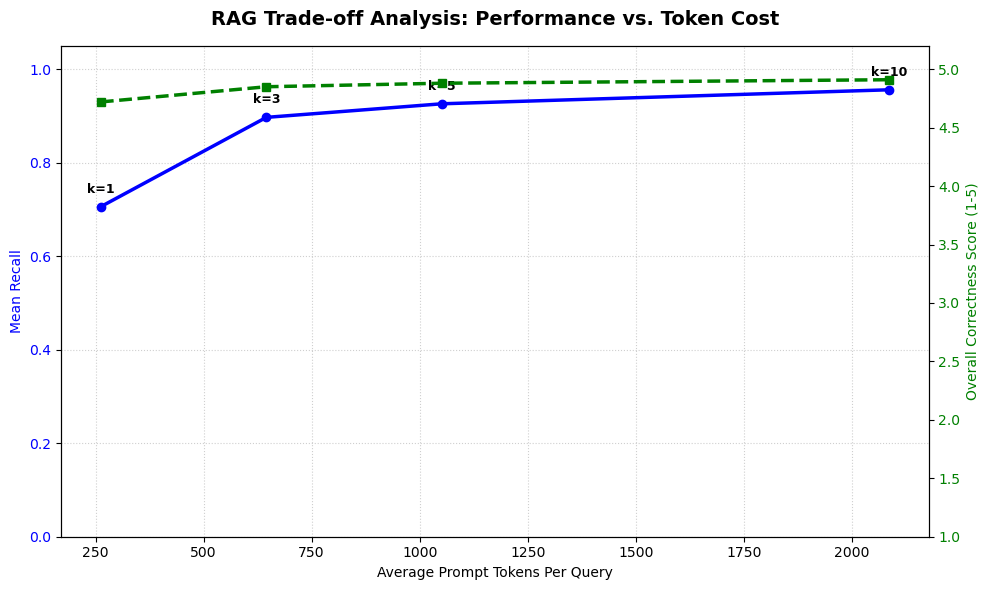

In [54]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.set_xlabel('Average Prompt Tokens Per Query')
ax1.set_ylabel('Mean Recall', color='b')
line1 = ax1.plot(
    k_tuning_df['Avg Prompt Tokens'], 
    k_tuning_df['Mean Recall'], 
    color='b', 
    marker='o', 
    linewidth=2.5, 
    label='Mean Recall'
)

ax1.tick_params(axis='y', labelcolor='b')
ax1.set_ylim(0, 1.05)

for i, txt in enumerate(k_tuning_df['k']):
    ax1.annotate(
        f"k={txt}", 
        (k_tuning_df['Avg Prompt Tokens'].iloc[i], k_tuning_df['Mean Recall'].iloc[i]),
        textcoords="offset points", 
        xytext=(0, 10), 
        ha='center', 
        fontsize=9,
        fontweight='bold'
    )

ax2 = ax1.twinx()
ax2.set_ylabel('Overall Correctness Score (1-5)', color='g')
line4 = ax2.plot(
    k_tuning_df['Avg Prompt Tokens'], 
    k_tuning_df['Overall Correctness'], 
    color='g', 
    marker='s', 
    linestyle='--', 
    linewidth=2.5, 
    label='Overall Correctness'
)

ax2.tick_params(axis='y', labelcolor='g')
ax2.set_ylim(1, 5.2)


plt.title('RAG Trade-off Analysis: Performance vs. Token Cost', fontsize=14, fontweight='bold', pad=15)
ax1.grid(True, linestyle=':', alpha=0.6)


plt.tight_layout()
plt.show()

### Evaluate Generation

In [55]:
def evaluate_generation(gold_dataset, vectorstore, llm, judge_llm, k=3):
    """
    Evaluate generated answers using an LLM judge.

    Scores:
    - Faithfulness: 1-5
    - Relevance: 1-5
    """

    results = []
    retriever = vectorstore.as_retriever(search_kwargs={"k": k})

    qa_chain = RetrievalQA.from_chain_type(
        llm=llm,
        chain_type="stuff",
        retriever=retriever,
        return_source_documents=True
    )

    total_queries = len(gold_dataset)

    for i, item in enumerate(gold_dataset, start=1):

        # print(f"Evaluating question {i}/{total_queries}...")

        query = item["query"]

        response = qa_chain.invoke({"query": query})

        generated_answer = response["result"]
        retrieved_docs = response["source_documents"]

        eval_scores = evaluate_single_generation(
            question=query,
            retrieved_docs=retrieved_docs,
            answer=generated_answer,
            judge_llm=judge_llm
        )

        results.append({
            "query": query,
            "answer": generated_answer,
            "faithfulness": eval_scores.get("faithfulness", 0),
            "relevance": eval_scores.get("relevance", 0),
            "reason": eval_scores.get("reason", ""),
            "retrieved_docs": retrieved_docs
        })

    return pd.DataFrame(results)

In [56]:
judge_results = evaluate_generation(gold_dataset, vectorstore_large, llm, judge_llm, k=3)

In [57]:
# print(judge_results)

In [58]:
print("Mean Faithfulness:",
      judge_results["faithfulness"].mean())

print("Mean Relevance:",
      judge_results["relevance"].mean())

Mean Faithfulness: 4.794117647058823
Mean Relevance: 4.970588235294118


### Cost

In [59]:
from datetime import datetime
from dataclasses import dataclass, asdict
from typing import Optional, Dict, List
import tiktoken

In [60]:
PRICING_DB = {
    # updated on 9/29/2026 to pricing per million tokens as is the new standard
    # prices for short context only
    
    # OpenAI / Azure OpenAI
    # https://openai.com/business/pricing/#api
    "gpt-5.6-sol": {"input": 4.00, "output": 20.00, "provider": "OpenAI/Azure"},  
    "gpt-4.1-mini": {"input": 0.40, "output": 1.60, "provider": "OpenAI/Azure"},
    "gpt-4o": {"input": 2.50, "output": 10.00, "provider": "OpenAI/Azure"},
    "gpt-4o-mini": {"input": 0.15, "output": 0.60, "provider": "OpenAI/Azure"},
    "gpt-4-turbo": {"input": 10.0, "output": 30.0, "provider": "OpenAI/Azure"},
    "gpt-3.5-turbo": {"input": 0.5, "output": 1.5, "provider": "OpenAI/Azure"},

    # Anthropic
    # https://platform.claude.com/docs/en/about-claude/pricing
    "claude-5.1-fable": {"input": 10.0, "output": 50.0, "provider": "Anthropic"},
    "claude-5.5-opus": {"input": 4.0, "output": 20.0, "provider": "Anthropic"},
    "claude-5.5-sonnnet": {"input": 2.0, "output": 10.0, "provider": "Anthropic"},
    "claude-4.5-haiku": {"input": 1.0, "output": 5.0, "provider": "Anthropic"},
    
    # Google
    # https://ai.google.dev/gemini-api/docs/pricing
    # Note... prices changing after 01/01/2027
    "gemini-3.8-flash": {"input": 0.75, "output": 3.75, "provider": "Google"},
    "gemini-3.7-flash": {"input": 0.75, "output": 3.75, "provider": "Google"},
    "gemini-3.6-flash": {"input": 0.75, "output": 3.75, "provider": "Google"},
    
    # Embeddings
    "text-embedding-ada-002": {"input": 0.1, "output": 0, "provider": "OpenAI/Azure"},
    "text-embedding-3-small": {"input": 0.02, "output": 0, "provider": "OpenAI"},
}

# Display pricing table
pricing_df = pd.DataFrame(PRICING_DB).T
# pricing_df["cost_per_1m_in"] = pricing_df["input"] * 1000
# pricing_df["cost_per_1m_out"] = pricing_df["output"] * 1000
print("Model Pricing (per 1M tokens):")
print(pricing_df[["provider", "input", "output"]].to_string())

Model Pricing (per 1M tokens):
                            provider input output
gpt-5.6-sol             OpenAI/Azure   4.0   20.0
gpt-4.1-mini            OpenAI/Azure   0.4    1.6
gpt-4o                  OpenAI/Azure   2.5   10.0
gpt-4o-mini             OpenAI/Azure  0.15    0.6
gpt-4-turbo             OpenAI/Azure  10.0   30.0
gpt-3.5-turbo           OpenAI/Azure   0.5    1.5
claude-5.1-fable           Anthropic  10.0   50.0
claude-5.5-opus            Anthropic   4.0   20.0
claude-5.5-sonnnet         Anthropic   2.0   10.0
claude-4.5-haiku           Anthropic   1.0    5.0
gemini-3.8-flash              Google  0.75   3.75
gemini-3.7-flash              Google  0.75   3.75
gemini-3.6-flash              Google  0.75   3.75
text-embedding-ada-002  OpenAI/Azure   0.1      0
text-embedding-3-small        OpenAI  0.02      0


In [61]:
@dataclass
class APICallRecord:
    """Record of a single API call."""
    timestamp: str
    model: str
    prompt_tokens: int
    completion_tokens: int
    total_tokens: int
    cost_usd: float
    latency_ms: float
    success: bool
    error: Optional[str] = None
    cache_hit: bool = False
    

class CostTracker:
    """Comprehensive cost tracking for LLM API calls."""
    
    def __init__(self, pricing_db: dict = None):
        self.pricing = pricing_db or PRICING_DB
        self.records: List[APICallRecord] = []
        
    def calculate_cost(self, model: str, prompt_tokens: int, completion_tokens: int) -> float:
        """Calculate cost for a given usage."""
        if model not in self.pricing:
            # Try to find a matching model
            model = "gpt-4.1-mini"  # Default fallback
        
        prices = self.pricing[model]
        input_cost = (prompt_tokens / 1E6) * prices["input"] # updated for cost per 1M tokens
        output_cost = (completion_tokens / 1E6) * prices["output"] # updated for cost per 1M tokens
        return input_cost + output_cost
    
    def record_call(self, response, model: str, latency_ms: float, 
                    cache_hit: bool = False, error: str = None):
        """Record an API call."""
        if error:
            record = APICallRecord(
                timestamp=datetime.now().isoformat(),
                model=model,
                prompt_tokens=0,
                completion_tokens=0,
                total_tokens=0,
                cost_usd=0,
                latency_ms=latency_ms,
                success=False,
                error=error,
                cache_hit=cache_hit
            )
        else:
            cost = self.calculate_cost(
                model,
                response.usage.prompt_tokens,
                response.usage.completion_tokens
            )
            record = APICallRecord(
                timestamp=datetime.now().isoformat(),
                model=model,
                prompt_tokens=response.usage.prompt_tokens,
                completion_tokens=response.usage.completion_tokens,
                total_tokens=response.usage.total_tokens,
                cost_usd=cost,
                latency_ms=latency_ms,
                success=True,
                cache_hit=cache_hit
            )
        
        self.records.append(record)
        return record
    
    def get_summary(self) -> dict:
        """Get summary statistics."""
        if not self.records:
            return {"error": "No records"}
        
        df = pd.DataFrame([asdict(r) for r in self.records])
        
        return {
            "total_calls": len(self.records),
            "successful_calls": df["success"].sum(),
            "total_tokens": df["total_tokens"].sum(),
            "total_cost_usd": df["cost_usd"].sum(),
            "avg_latency_ms": df["latency_ms"].mean(),
            "cache_hit_rate": df["cache_hit"].mean() if "cache_hit" in df else 0,
            "cost_per_call": df["cost_usd"].mean(),
            "by_model": df.groupby("model")["cost_usd"].sum().to_dict()
        }
    
    def to_dataframe(self) -> pd.DataFrame:
        """Convert records to DataFrame."""
        return pd.DataFrame([asdict(r) for r in self.records])
    
    def print_summary(self):
        """Print formatted summary."""
        s = self.get_summary()
        print("\n" + "="*50)
        print("COST TRACKING SUMMARY")
        print("="*50)
        print(f"Total API calls: {s['total_calls']}")
        print(f"Successful calls: {s['successful_calls']}")
        print(f"Total tokens: {s['total_tokens']:,}")
        print(f"Total cost: ${s['total_cost_usd']:.6f}")
        print(f"Average latency: {s['avg_latency_ms']:.0f}ms")
        print(f"Cache hit rate: {s['cache_hit_rate']:.1%}")
        print(f"Average cost per call: ${s['cost_per_call']:.6f}")
        print("\nCost by model:")
        for model, cost in s['by_model'].items():
            print(f"  {model}: ${cost:.6f}")


# Initialize global tracker
tracker = CostTracker()
print("Cost tracker initialized!")

Cost tracker initialized!


In [62]:
import time
from langchain_community.callbacks import get_openai_callback
# https://reference.langchain.com/python/langchain-community/callbacks/manager/get_openai_callback

In [63]:
def evaluate_costs(gold_dataset, qa_chains_dict, model=CHAT_MODEL):
    """
    evaluates RAG chains for token usage, estimated cost, and latency using get_openai_callback.
    """
    summary_results = []

    cost_tracker = CostTracker()
    
    for strategy_name, qa_chain in qa_chains_dict.items():
        # set scores
        total_prompt_tokens = 0
        total_completion_tokens = 0
        total_tokens = 0
        total_cost = 0.0
        total_latency = 0.0
        
        total_queries = len(gold_dataset)

        for item in gold_dataset:
            query = item["query"]

            # start timer
            start_time = time.perf_counter()

            # wrap the call with get_openai_callback()
            with get_openai_callback() as cb:
                response = qa_chain.invoke({"query": query})

            # stop timer
            end_time = time.perf_counter()
            query_latency = end_time - start_time
            
            # update metrics
            total_prompt_tokens += cb.prompt_tokens
            total_completion_tokens += cb.completion_tokens
            total_tokens += cb.total_tokens
            total_latency += query_latency

            # uses info from pricing database
            # With some help from AI to increase the abstraction here
            # now uses whichever chat_model is defined at the top and NOT hardcoded in a function!!!
            total_cost += cost_tracker.calculate_cost(
                model=model,
                prompt_tokens=cb.prompt_tokens,
                completion_tokens=cb.completion_tokens
            )

        # calculate averages 
        summary_results.append({
            "Strategy": strategy_name,
            "Avg Prompt Tokens": round(total_prompt_tokens / total_queries, 2),
            "Avg Completion Tokens": round(total_completion_tokens / total_queries, 2),
            "Avg Total Tokens": round(total_tokens / total_queries, 2),
            "Avg Latency (s)": round(total_latency / total_queries, 3),
            "Total Cost ($)": round(total_cost, 6)
        })

    return pd.DataFrame(summary_results)

In [64]:
# chains dictionary (similar strategy as the retrieval system, but with the chains now)
qa_chains = {
    "Small Chunks (500/50)": qa_chain_small,
    "Large Chunks (1000/50)": qa_chain_large,
    "Large Chunks High Overlap (1000/200)": qa_chain_large_overlap
}



In [65]:
cost_results = evaluate_costs(gold_dataset, qa_chains)

print("--- Cost & Performance Efficiency Comparison ---")
print(cost_results.to_string(index=False))

--- Cost & Performance Efficiency Comparison ---
                            Strategy  Avg Prompt Tokens  Avg Completion Tokens  Avg Total Tokens  Avg Latency (s)  Total Cost ($)
               Small Chunks (500/50)             438.68                  68.06            506.74            1.518        0.009668
              Large Chunks (1000/50)             645.24                  91.76            737.00            1.688        0.013767
Large Chunks High Overlap (1000/200)             662.97                  85.53            748.50            1.741        0.013669


In [66]:
def project_costs(requests_per_day: int, avg_input_tokens: int, 
                  avg_output_tokens: int, model: str = "gpt-4.1-mini",
                  cache_hit_rate: float = 0.0) -> dict:
    """Project costs at scale."""
    tracker_temp = CostTracker()
    
    # Effective requests (accounting for cache)
    effective_requests = requests_per_day * (1 - cache_hit_rate)
    
    # Cost per request
    cost_per_request = tracker_temp.calculate_cost(model, avg_input_tokens, avg_output_tokens)
    
    daily_cost = effective_requests * cost_per_request
    monthly_cost = daily_cost * 30
    yearly_cost = daily_cost * 365
    
    return {
        "model": model,
        "requests_per_day": requests_per_day,
        "effective_requests": effective_requests,
        "cache_hit_rate": cache_hit_rate,
        "cost_per_request": cost_per_request,
        "daily_cost": daily_cost,
        "monthly_cost": monthly_cost,
        "yearly_cost": yearly_cost
    }



In [67]:
# Project costs for different scenarios
scenarios = [
    {"name": "Small App", "requests": 1000, "input": 500, "output": 200},
    {"name": "Medium App", "requests": 10000, "input": 500, "output": 200},
    {"name": "Large App", "requests": 100000, "input": 500, "output": 200},
]

models_to_compare = ["gpt-4o-mini", "claude-4.5-haiku","gpt-4o",]

print("Cost Projections (Monthly):")
print("="*80)

for scenario in scenarios:
    print(f"\n{scenario['name']} ({scenario['requests']:,} requests/day):")
    for model in models_to_compare:
        proj = project_costs(
            scenario["requests"],
            scenario["input"],
            scenario["output"],
            model
        )
        print(f"  {model:20s}: ${proj['monthly_cost']:>10,.2f}/month")


Cost Projections (Monthly):

Small App (1,000 requests/day):
  gpt-4o-mini         : $      5.85/month
  claude-4.5-haiku    : $     45.00/month
  gpt-4o              : $     97.50/month

Medium App (10,000 requests/day):
  gpt-4o-mini         : $     58.50/month
  claude-4.5-haiku    : $    450.00/month
  gpt-4o              : $    975.00/month

Large App (100,000 requests/day):
  gpt-4o-mini         : $    585.00/month
  claude-4.5-haiku    : $  4,500.00/month
  gpt-4o              : $  9,750.00/month
